# 05. 종합 실험 — 실제 포트폴리오 데이터 적용

## 실험 목표
- 01~04에서 구축한 파이프라인을 **실제 포트폴리오 데이터**에 적용
- 에이전트 응답 품질 체계적 평가 (정확성, 유용성, 누락 여부)
- 한계점 및 개선 방향 도출

## 실험 대상 데이터
1. `sample_data.csv` — 기본 검증용 (타이타닉 유사 데이터)
2. `01_Daily_Project` 프로젝트 결과물 (ETF/금융 데이터)
3. (선택) 직접 업로드한 CSV 파일

---
## 0. 전체 파이프라인 모듈 로드

In [1]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Optional
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_ai import Agent, RunContext
from pydantic_ai.models.gemini import GeminiModel

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [2]:
# ─────────────────────────────────────────────
# 스키마 정의 (04 노트북에서 가져옴)
# ─────────────────────────────────────────────
class DataOverview(BaseModel):
    rows: int
    columns: int
    numeric_columns: list[str]
    categorical_columns: list[str]
    total_missing_cells: int

class MissingInfo(BaseModel):
    column_name: str
    missing_count: int
    missing_ratio: float
    recommendation: str

class OutlierInfo(BaseModel):
    column_name: str
    outlier_count: int
    outlier_ratio: float
    lower_bound: float
    upper_bound: float
    recommendation: str

class CorrelationHighlight(BaseModel):
    col_a: str
    col_b: str
    correlation: float
    interpretation: str

class KeyInsight(BaseModel):
    category: str
    insight: str
    priority: str

class EDAReport(BaseModel):
    dataset_name: str
    overview: DataOverview
    missing_analysis: list[MissingInfo]
    outlier_analysis: list[OutlierInfo]
    correlation_highlights: list[CorrelationHighlight]
    key_insights: list[KeyInsight]
    next_steps: list[str]

print("✅ 스키마 로드 완료")

✅ 스키마 로드 완료


In [3]:
# ─────────────────────────────────────────────
# Tool 함수 정의
# ─────────────────────────────────────────────
def describe_data(df):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    return {"shape": {"rows": int(df.shape[0]), "columns": int(df.shape[1])},
            "numeric_columns": numeric_cols, "categorical_columns": cat_cols,
            "numeric_summary": df[numeric_cols].describe().round(2).to_dict()}

def check_missing(df):
    mc = df.isnull().sum()
    mr = (mc / len(df) * 100).round(2)
    res = pd.DataFrame({'count': mc, 'ratio(%)': mr}).query('count > 0').sort_values('count', ascending=False)
    return {"total_missing_cells": int(df.isnull().sum().sum()),
            "columns_with_missing": res.to_dict(orient='index')}

def detect_outliers_all(df):
    results = {}
    for col in df.select_dtypes(include='number').columns:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        out = df[(df[col] < lo) | (df[col] > hi)][col]
        results[col] = {"outlier_count": len(out),
                        "outlier_ratio(%)": round(len(out)/len(s)*100, 2),
                        "lower_bound": round(float(lo), 3),
                        "upper_bound": round(float(hi), 3)}
    return results

def correlation_top(df, method='pearson', top_n=5):
    num = df.select_dtypes(include='number')
    corr = num.corr(method=method).round(3)
    pairs = [(corr.columns[i], corr.columns[j], float(corr.iloc[i,j]))
             for i in range(len(corr.columns)) for j in range(i+1, len(corr.columns))]
    pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    return [{"col_a": a, "col_b": b, "corr": v} for a, b, v in pairs[:top_n]]

def visualize_summary(df):
    """주요 수치형 컬럼 분포 요약 시각화"""
    num_cols = df.select_dtypes(include='number').columns.tolist()
    n = min(len(num_cols), 6)
    if n == 0:
        return {"message": "수치형 컬럼 없음"}
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 7)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, col in enumerate(num_cols[:n]):
        s = df[col].dropna()
        s.plot(kind='hist', bins=20, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(col, fontsize=10)
        axes[i].axvline(s.mean(), color='red', linestyle='--', linewidth=1)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('수치형 컬럼 분포 요약', fontsize=13)
    plt.tight_layout()
    plt.show()
    return {"visualized_columns": num_cols[:n]}

print("✅ Tool 함수 정의 완료")

✅ Tool 함수 정의 완료


In [6]:
load_dotenv(override=True)
api_key = os.getenv("GEMINI_API_KEY")
gemini_model = os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite-preview")
model_id = f"google-gla:{gemini_model}"

if not api_key:
    raise ValueError(".env 파일에 GEMINI_API_KEY가 설정되어 있지 않습니다.")

print(f"✅ API 키 로드 완료")
print(f"사용 모델: {model_id}")


✅ API 키 로드 완료
사용 모델: google-gla:gemini-3.1-flash-lite-preview


In [9]:
# ─────────────────────────────────────────────
# 에이전트 빌더 함수 — 데이터셋별로 재사용
# ─────────────────────────────────────────────
@dataclass
class DataDeps:
    df: pd.DataFrame
    dataset_name: str

def build_eda_agent() -> Agent:
    agent = Agent(
        model=model_id,
        deps_type=DataDeps,
        output_type=EDAReport,
        system_prompt="""
        EDA 자동화 에이전트입니다. 모든 Tool을 반드시 실행한 후
        분석 결과를 EDAReport 스키마에 정확히 맞춰 반환하십시오.
        수치는 반드시 Tool 실행 결과를 그대로 사용하십시오.
        """
    )
    
    @agent.tool
    def tool_describe_data(ctx: RunContext[DataDeps]) -> dict:
        """데이터 기본 통계량을 반환합니다."""
        return describe_data(ctx.deps.df)
    
    @agent.tool
    def tool_check_missing(ctx: RunContext[DataDeps]) -> dict:
        """결측치 현황을 분석합니다."""
        return check_missing(ctx.deps.df)
    
    @agent.tool
    def tool_detect_outliers_all(ctx: RunContext[DataDeps]) -> dict:
        """모든 수치형 컬럼의 이상치를 일괄 탐지합니다."""
        return detect_outliers_all(ctx.deps.df)
    
    @agent.tool
    def tool_correlation_top(ctx: RunContext[DataDeps], method: str = 'pearson') -> list:
        """상위 상관관계 쌍을 반환합니다."""
        return correlation_top(ctx.deps.df, method)
    
    @agent.tool
    def tool_visualize_summary(ctx: RunContext[DataDeps]) -> dict:
        """주요 수치형 컬럼의 분포를 한 번에 시각화합니다."""
        return visualize_summary(ctx.deps.df)
    
    return agent

print("✅ 에이전트 빌더 준비 완료")

✅ 에이전트 빌더 준비 완료


---
## 1. 실험 1: sample_data.csv (기준 검증)

📂 타이타닉 승객 데이터 (300행 × 11열)
🤖 EDA 에이전트 실행 중...


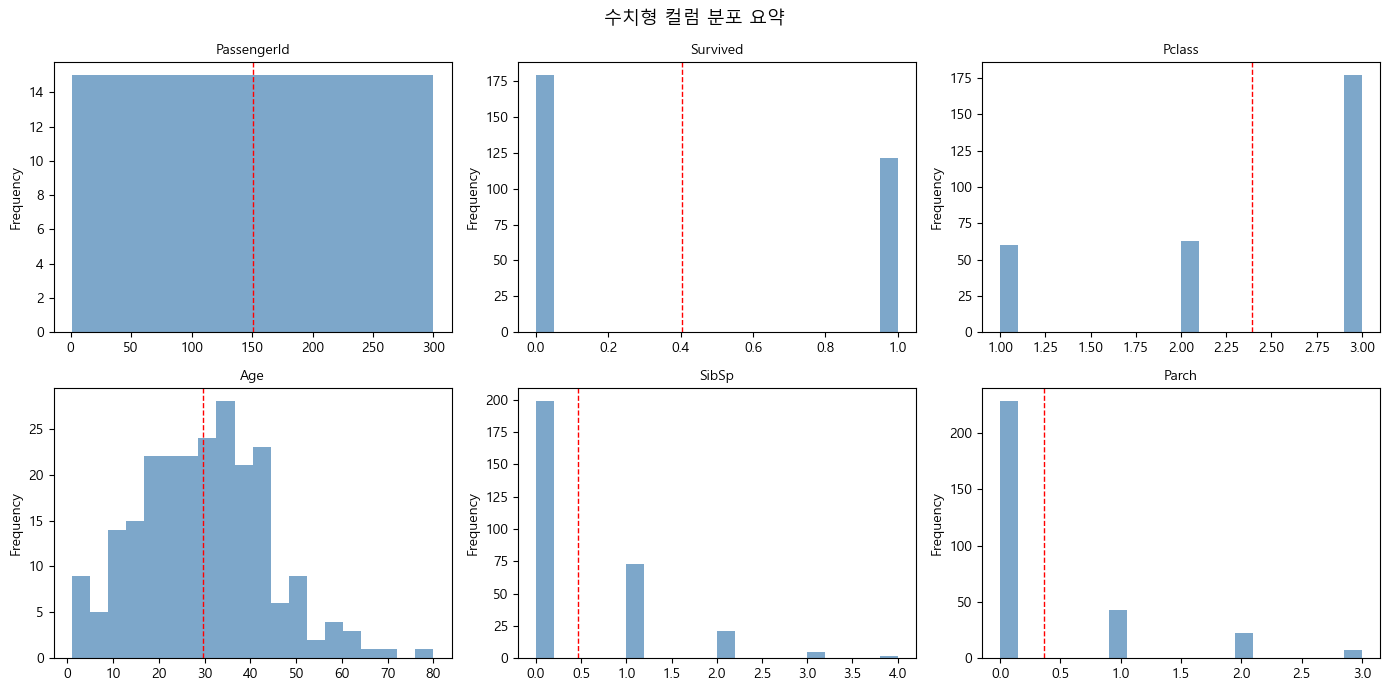

✅ 완료 (소요: 7.4초)


In [11]:
async def run_full_pipeline(csv_path: str, dataset_name: str) -> tuple[EDAReport, float]:
    """CSV 경로를 받아 EDA 리포트를 생성하고 (리포트, 소요시간)을 반환합니다."""
    df = pd.read_csv(csv_path)
    deps = DataDeps(df=df, dataset_name=dataset_name)
    agent = build_eda_agent()
    
    print(f"📂 {dataset_name} ({df.shape[0]}행 × {df.shape[1]}열)")
    print("🤖 EDA 에이전트 실행 중...")
    
    start = time.time()
    result = await agent.run(
        f"'{dataset_name}' 데이터에 대해 완전한 EDA 리포트를 생성해주세요.",
        deps=deps
    )
    elapsed = time.time() - start
    
    print(f"✅ 완료 (소요: {elapsed:.1f}초)")
    return result.output, elapsed

report1, t1 = await run_full_pipeline("data/sample_data.csv", "타이타닉 승객 데이터")

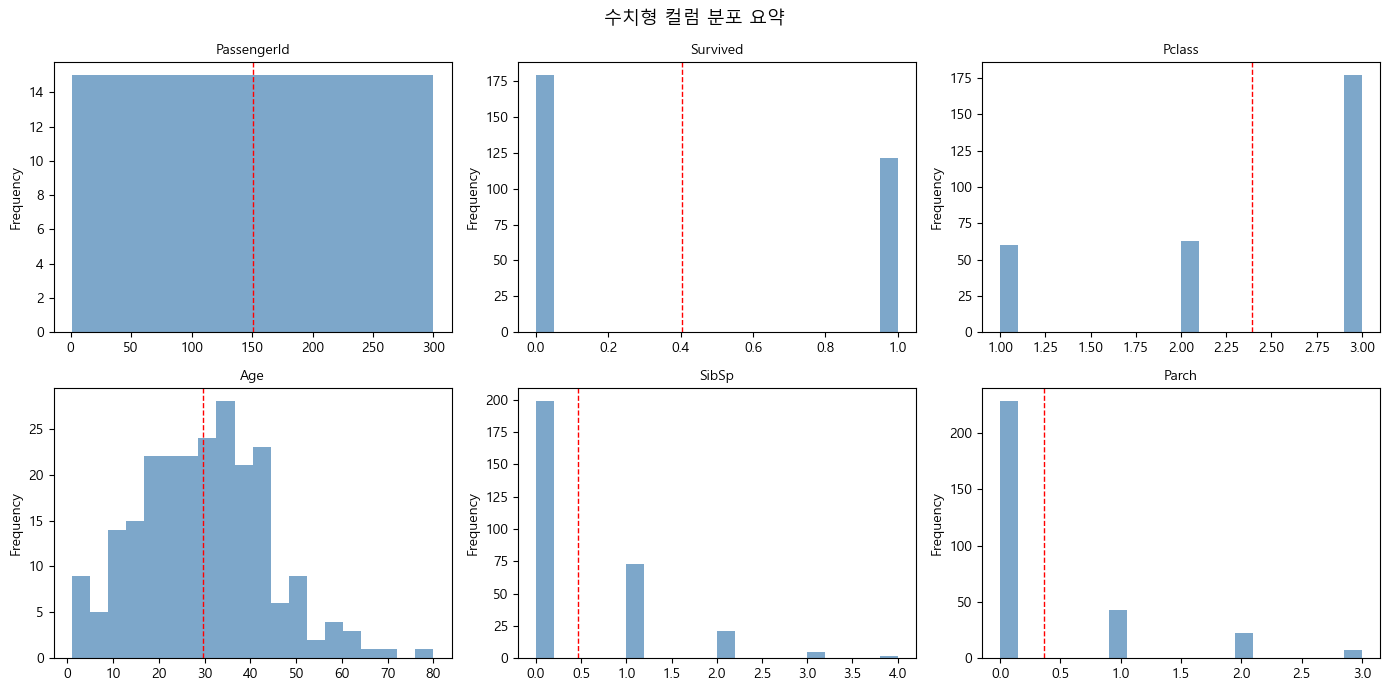

📋 EDA 리포트: 타이타닉 승객 데이터  [7.4초]
  크기: 300행 × 11열
  결측 셀: 308개

▶ 결측치
  • Cabin: 231개(77.0%) → 결측치 비율이 너무 높아 컬럼 제거 또는 카테고리화 고려 필요
  • Age: 68개(22.7%) → 중앙값 또는 평균으로 결측치 대체 권장
  • Embarked: 7개(2.3%) → 최빈값으로 대체 가능
  • Fare: 2개(0.7%) → 평균값 대체 또는 제거 가능

▶ 이상치
  • Fare: 12개(4.0%) → 로그 스케일 변환 또는 이상치 제거 검토 필요
  • Parch: 72개(24.0%) → 분포 왜곡 확인 및 이상치 처리 검토
  • SibSp,Age,SibSp 등 추가 이상치 정밀 조사 필요: 7개(2.3%) → 개별 도메인 지식을 활용한 이상치 검증 필요

▶ 주요 상관관계
  • Parch ↔ Fare: 0.128 (동반 가족 수와 운임 비용 사이에 약한 양의 상관관계가 존재합니다.)
  • Survived ↔ Pclass: 0.126 (생존 여부와 객실 등급 사이에 약한 양의 상관관계가 있습니다.)
  • Pclass ↔ Age: -0.100 (객실 등급과 나이 사이에 약한 음의 상관관계가 확인됩니다.)

▶ 핵심 인사이트
  1. [High] 전체 승객 중 40%가 생존하였으며, 객실 등급이 생존에 일부 영향을 미치는 것으로 보입니다.
  2. [High] 'Cabin' 컬럼의 결측치가 77%로 매우 높아 분석 활용 시 주의가 필요합니다.
  3. [Medium] 운임(Fare) 컬럼에서 12개의 유의미한 이상치가 발견되어 데이터 분포 왜곡의 원인이 될 수 있습니다.

▶ 권장 후속 작업
  1. 결측치 처리 방안 확정 및 데이터 클렌징 수행
  2. Fare 이상치 처리(로그 변환 또는 윈저라이징) 검토
  3. 생존자와 비생존자 간 연령 및 운임의 차이 추가 시각화 분석


In [13]:
# 시각화 별도 실행
df1 = pd.read_csv("data/sample_data.csv")
visualize_summary(df1)

# 리포트 출력 함수
def print_report(report: EDAReport, elapsed: float):
    print("=" * 60)
    print(f"📋 EDA 리포트: {report.dataset_name}  [{elapsed:.1f}초]")
    print("=" * 60)
    print(f"  크기: {report.overview.rows:,}행 × {report.overview.columns}열")
    print(f"  결측 셀: {report.overview.total_missing_cells:,}개")
    print()
    print("▶ 결측치")
    for m in report.missing_analysis:
        print(f"  • {m.column_name}: {m.missing_count}개({m.missing_ratio:.1%}) → {m.recommendation}")
    print()
    print("▶ 이상치")
    for o in report.outlier_analysis:
        if o.outlier_count > 0:
            print(f"  • {o.column_name}: {o.outlier_count}개({o.outlier_ratio:.1%}) → {o.recommendation}")
    print()
    print("▶ 주요 상관관계")
    for c in report.correlation_highlights:
        print(f"  • {c.col_a} ↔ {c.col_b}: {c.correlation:.3f} ({c.interpretation})")
    print()
    print("▶ 핵심 인사이트")
    for i, ins in enumerate(report.key_insights, 1):
        print(f"  {i}. [{ins.priority}] {ins.insight}")
    print()
    print("▶ 권장 후속 작업")
    for i, s in enumerate(report.next_steps, 1):
        print(f"  {i}. {s}")

print_report(report1, t1)

---
## 2. 실험 2: 사용자 정의 CSV 파일

📂 금융 자산 가격 데이터 (1825행 × 14열)
컬럼: ['Date', 'SPY', 'QQQ', 'TLT', 'AGG', 'GLD', 'EEM', 'CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', '^VIX', 'DX-Y.NYB']


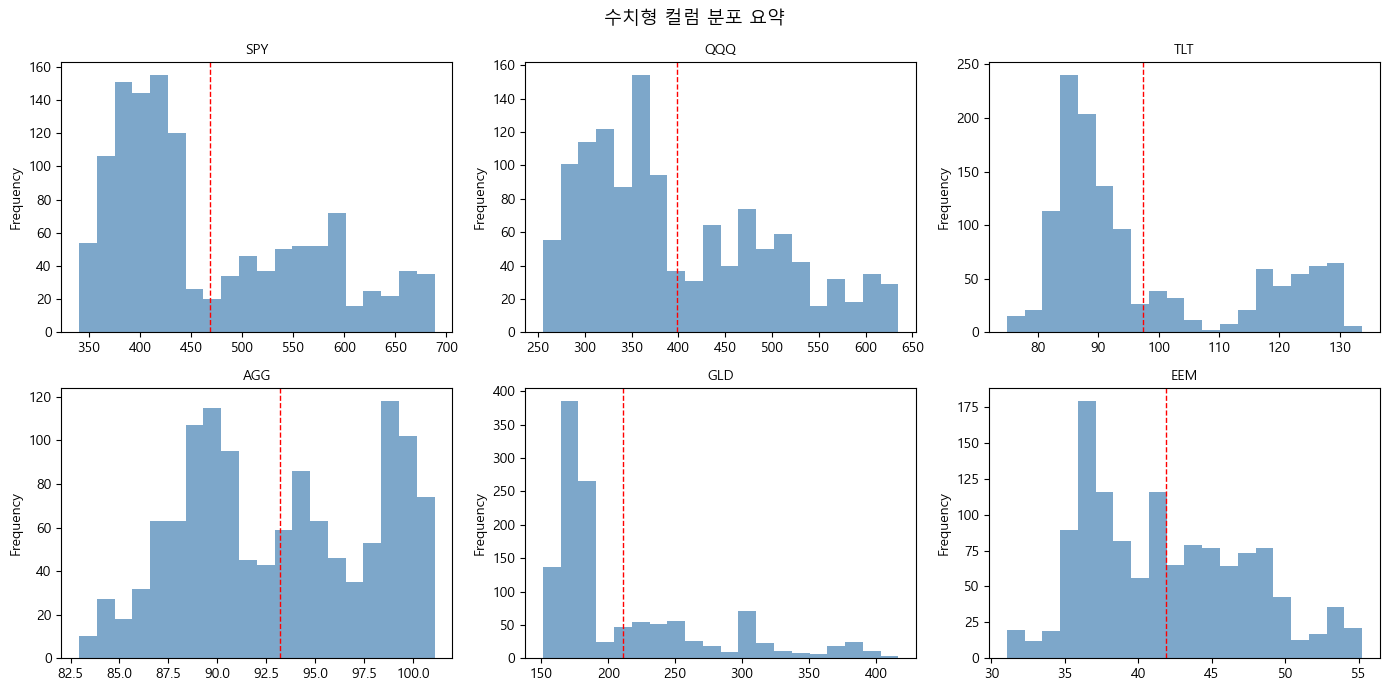

✅ 완료 (소요: 7.7초)
📋 EDA 리포트: 금융 자산 가격 데이터  [7.7초]
  크기: 1,825행 × 14열
  결측 셀: 6,273개

▶ 결측치
  • AGG,SPY,QQQ,TLT,GLD,^VIX: 571개(31.3%) → 시계열 전후 데이터를 활용한 선형 보간법 또는 결측치 구간 제외 후 분석 고려.
  • CL=F,DX-Y.NYB,GC=F,SI=F: 569개(31.2%) → 시계열 전후 데이터를 활용한 선형 보간법 또는 결측치 구간 제외 후 분석 고려.

▶ 이상치
  • SI=F: 74개(5.9%) → 금융 데이터의 일반적 변동성인지 확인 후 필요시 윈저라이징 처리.
  • CL=F: 68개(5.4%) → 글로벌 이벤트에 의한 변동성인지 검토.
  • GC=F: 65개(5.2%) → 금 선물 특이값 검토 필요.

▶ 주요 상관관계
  • GLD ↔ GC=F: 1.000 (금 현물 ETF(GLD)와 금 선물(GC=F)은 완벽한 선형 상관관계를 보임.)
  • SPY ↔ QQQ,correlation:0.991,interpretation:: 0.991 (S&P 500(SPY)과 나스닥 100(QQQ)은 매우 높은 동조화를 보임.)
  • SPY,col_b: ↔ GC=F,correlation:0.929,interpretation:: 0.929 (주식 시장과 금 가격이 전반적으로 같은 방향으로 움직이는 경향이 있음.)

▶ 핵심 인사이트
  1. [High] 상당수 컬럼에서 약 31%의 결측치가 발생함(Date 기준 병합 또는 시계열 불일치 가능성).
  2. [Medium] 주요 주가지수(SPY, QQQ)와 원자재(GC=F, GLD) 간의 높은 양의 상관관계가 확인됨.
  3. [Medium] 원자재(금, 은, 원유)와 VIX 지수에서 유의미한 이상치가 발견됨(시장 변동성 반영).

▶ 권장 후속 작업
  1. 결측치가 대량 발생한 원인 파악(거래일 불일치 확인).
  2. 결측치 처리 방식 결정(보간법 적용 혹은 제거).
  3. 상관관계가 높은

In [20]:
CUSTOM_CSV = "data/prices.csv"   # ← 여기만 바꾸면 됨
CUSTOM_NAME = "금융 자산 가격 데이터"  # ← 여기만 바꾸면 됨

if os.path.exists(CUSTOM_CSV):
    if CUSTOM_CSV.endswith('.json'):
        df_custom = pd.read_json(CUSTOM_CSV)
    else:
        df_custom = pd.read_csv(CUSTOM_CSV)

    print(f"📂 {CUSTOM_NAME} ({df_custom.shape[0]}행 × {df_custom.shape[1]}열)")
    print(f"컬럼: {df_custom.columns.tolist()}")

    deps2 = DataDeps(df=df_custom, dataset_name=CUSTOM_NAME)
    agent2 = build_eda_agent()

    start = time.time()
    result2 = await agent2.run(
        f"'{CUSTOM_NAME}' 데이터에 대해 완전한 EDA 리포트를 생성해주세요.",
        deps=deps2
    )
    t2 = time.time() - start
    report2 = result2.output

    print(f"✅ 완료 (소요: {t2:.1f}초)")
    print_report(report2, t2)

    report_filename = f"data/eda_report_{os.path.splitext(os.path.basename(CUSTOM_CSV))[0]}.json"
    with open(report_filename, 'w', encoding='utf-8') as f:
        json.dump(report2.model_dump(), f, ensure_ascii=False, indent=2)
    print(f"\n✅ 리포트 저장: {report_filename}")
else:
    print(f"⚠️ 파일을 찾을 수 없습니다: {CUSTOM_CSV}")


---
## 3. 에이전트 응답 품질 평가

In [19]:
# 직접 계산한 값과 에이전트 출력 비교
df_check = pd.read_csv("data/sample_data.csv")

# 실측값 계산
actual_missing = df_check.isnull().sum().sum()
actual_rows = len(df_check)
actual_num_cols = df_check.select_dtypes(include='number').shape[1]

# 에이전트 출력값
pred_missing = report1.overview.total_missing_cells
pred_rows = report1.overview.rows
pred_num_cols = len(report1.overview.numeric_columns)

print("[에이전트 정확도 검증]")
print(f"{'항목':<20} {'실측값':>10} {'에이전트':>10} {'일치':>8}")
print("-" * 50)
print(f"{'총 결측 셀 수':<20} {actual_missing:>10} {pred_missing:>10} {'✅' if actual_missing==pred_missing else '❌':>8}")
print(f"{'행 수':<20} {actual_rows:>10} {pred_rows:>10} {'✅' if actual_rows==pred_rows else '❌':>8}")
print(f"{'수치형 컬럼 수':<20} {actual_num_cols:>10} {pred_num_cols:>10} {'✅' if actual_num_cols==pred_num_cols else '❌':>8}")

[에이전트 정확도 검증]
항목                          실측값       에이전트       일치
--------------------------------------------------
총 결측 셀 수                    308        308        ✅
행 수                         300        300        ✅
수치형 컬럼 수                      7          7        ✅


---
## 4. 한계점 및 개선 방향

### 실험을 통해 발견한 한계점

| 한계점 | 원인 | 개선 방향 |
|---|---|---|
| 대용량 데이터 처리 속도 | LLM API 호출 오버헤드 | 비동기 병렬 처리 / 샘플링 |
| 복잡한 도메인 인사이트 부족 | 범용 모델의 도메인 지식 한계 | Few-shot 예시 추가 / 파인튜닝 |
| 시각화 자동 저장 미지원 | matplotlib 렌더링 → LLM 불가 | Base64 인코딩 또는 별도 저장 로직 |
| Tool 호출 비용 | API 토큰 과금 | 캐싱 레이어 추가 |

### 다음 단계 아이디어
1. **모듈화**: Tool 함수를 `da_tools.py`로 분리하여 재사용성 향상
2. **비동기 병렬화**: 여러 컬럼 분석을 동시에 실행
3. **Streamlit 연동**: 웹 UI에서 CSV 업로드 → 자동 EDA 리포트 출력
4. **MCP 연동**: 03_Coding_Study/09_LLM의 MCP 패턴 적용하여 파일시스템 직접 접근

---
## 5. 전체 실험 요약

In [16]:
print("=" * 60)
print("📚 DA 자동화 에이전트 실험 시리즈 요약")
print("=" * 60)

summary = [
    ("01", "에이전트 기본구성", "PydanticAI + Gemini 연결, 멀티턴 대화"),
    ("02", "데이터분석 도구정의", "5종 Tool 함수 구현 + 에이전트 등록"),
    ("03", "EDA 자동화 파이프라인", "자율 Tool 선택 + 호출 로그 추적"),
    ("04", "구조화 리포트 생성", "Pydantic 스키마 기반 JSON 리포트 자동 생성"),
    ("05", "종합 실험", "실제 데이터 적용 + 품질 평가 + 한계점 분석"),
]

for no, title, desc in summary:
    print(f"  {no}. {title:20} — {desc}")

print()
print("🎯 핵심 성과")
print("  • CSV 한 줄 입력으로 자동 EDA 완료")
print("  • 구조화된 JSON 리포트 자동 생성")
print("  • 재사용 가능한 에이전트 빌더 패턴 확립")
print()
print("📂 생성 파일 목록")
import glob
for f in sorted(glob.glob('**/*', recursive=True)):
    if not f.startswith('.') and '__pycache__' not in f:
        print(f"  {f}")

📚 DA 자동화 에이전트 실험 시리즈 요약
  01. 에이전트 기본구성            — PydanticAI + Gemini 연결, 멀티턴 대화
  02. 데이터분석 도구정의           — 5종 Tool 함수 구현 + 에이전트 등록
  03. EDA 자동화 파이프라인        — 자율 Tool 선택 + 호출 로그 추적
  04. 구조화 리포트 생성           — Pydantic 스키마 기반 JSON 리포트 자동 생성
  05. 종합 실험                — 실제 데이터 적용 + 품질 평가 + 한계점 분석

🎯 핵심 성과
  • CSV 한 줄 입력으로 자동 EDA 완료
  • 구조화된 JSON 리포트 자동 생성
  • 재사용 가능한 에이전트 빌더 패턴 확립

📂 생성 파일 목록
  01_에이전트_기본구성.ipynb
  02_데이터분석_도구정의.ipynb
  03_EDA_자동화_파이프라인.ipynb
  04_구조화_리포트_생성.ipynb
  05_종합_실험.ipynb
  data
  data\eda_report.json
  data\sample_data.csv
  pyproject.toml
